In [1]:
import pandas as pd

gen = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

print(gen.shape)
print(weather.shape)
print(gen.columns.tolist())
print(weather.columns.tolist())

(68778, 7)
(3182, 6)
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


In [2]:
print(gen.head())
print("\n")
print(weather.head())

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  


             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2020-05-15 01:00:00   41

In [3]:
print(gen.dtypes)
print("\n")
print(gen.isnull().sum())
print("\n")
print(gen["SOURCE_KEY"].nunique())

DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object


DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


22


In [2]:
gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"], dayfirst=True)
weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"])

df = pd.merge(gen, weather, on="DATE_TIME", how="left")

print(df.shape)
print(df.head())

(68778, 12)
   DATE_TIME  PLANT_ID_x     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15     4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15     4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15     4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15     4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15     4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  PLANT_ID_y     SOURCE_KEY_y  AMBIENT_TEMPERATURE  \
0    6259559.0   4135001.0  HmiyD2TTLFNqkNe            25.184316   
1    6183645.0   4135001.0  HmiyD2TTLFNqkNe            25.184316   
2    6987759.0   4135001.0  HmiyD2TTLFNqkNe            25.184316   
3    7602960.0   4135001.0  HmiyD2TTLFNqkNe            25.184316   
4    7158964.0   4135001.0  HmiyD2TTLFNqkNe            25.184316   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.857507          0.0  

In [3]:
df = df.drop(columns=["PLANT_ID_y", "SOURCE_KEY_y"])
df = df.rename(columns={"PLANT_ID_x": "PLANT_ID", "SOURCE_KEY_x": "SOURCE_KEY"})

print(df.columns.tolist())
print(df.shape)

['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
(68778, 10)


In [6]:
print(df.isnull().sum())

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    4
MODULE_TEMPERATURE     4
IRRADIATION            4
dtype: int64


In [4]:
for col in ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]:
    df[col] = df[col].fillna(df[col].mean())

print(df.isnull().sum())

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [5]:
df["hour"] = df["DATE_TIME"].dt.hour
df["month"] = df["DATE_TIME"].dt.month

print(df[["DATE_TIME", "hour", "month"]].head())

   DATE_TIME  hour  month
0 2020-05-15     0      5
1 2020-05-15     0      5
2 2020-05-15     0      5
3 2020-05-15     0      5
4 2020-05-15     0      5


In [6]:
features = ["DC_POWER", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE",
            "IRRADIATION", "hour", "month"]

X = df[features]
y = df["AC_POWER"]

print(X.shape)
print(y.shape)

(68778, 6)
(68778,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(55022, 6)
(13756, 6)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — RMSE: {rmse_lr:.2f}, R²: {r2_lr:.4f}")

Linear Regression — RMSE: 1.44, R²: 1.0000


In [9]:
features = ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE",
            "IRRADIATION", "hour", "month"]

X = df[features]
y = df["AC_POWER"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — RMSE: {rmse_lr:.2f}, R²: {r2_lr:.4f}")

Linear Regression — RMSE: 56.71, R²: 0.9792


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest — RMSE: {rmse_rf:.2f}, R²: {r2_rf:.4f}")

Random Forest — RMSE: 46.94, R²: 0.9857


In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost — RMSE: {rmse_xgb:.2f}, R²: {r2_xgb:.4f}")

XGBoost — RMSE: 46.87, R²: 0.9858


In [13]:
print(f"Linear Regression — RMSE: {rmse_lr:.2f}, R²: {r2_lr:.4f}")
print(f"Random Forest     — RMSE: {rmse_rf:.2f}, R²: {r2_rf:.4f}")
print(f"XGBoost           — RMSE: {rmse_xgb:.2f}, R²: {r2_xgb:.4f}")

Linear Regression — RMSE: 56.71, R²: 0.9792
Random Forest     — RMSE: 46.94, R²: 0.9857
XGBoost           — RMSE: 46.87, R²: 0.9858


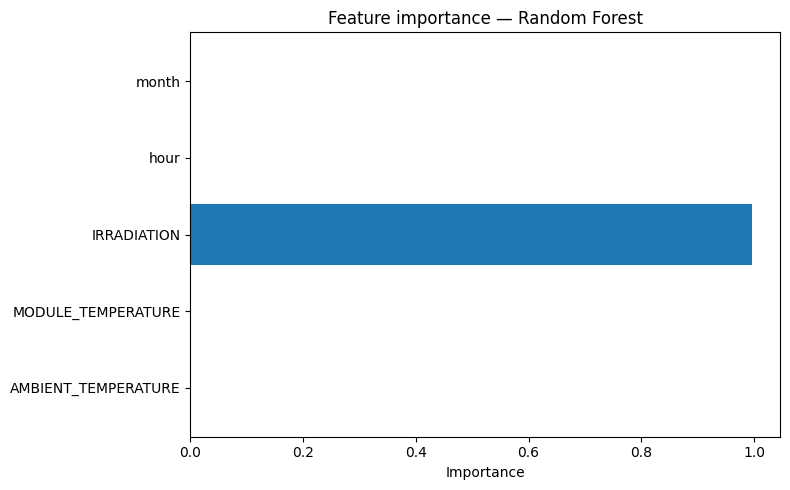

In [14]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feat_names = features

plt.figure(figsize=(8, 5))
plt.barh(feat_names, importances)
plt.xlabel("Importance")
plt.title("Feature importance — Random Forest")
plt.tight_layout()
plt.show()